In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Unemployment_data.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:

df[' Date'] = df[' Date'].str.strip()
df[' Date'] = pd.to_datetime(df[' Date'], format="%d-%m-%Y")

In [ ]:
df['Year'] = df[' Date'].dt.year
df['Month'] = df[' Date'].dt.month

In [ ]:
df[' Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

In [ ]:
df[' Estimated Unemployment Rate (%)'].max()

76.74

In [ ]:
df[' Estimated Unemployment Rate (%)'].min()

0.0

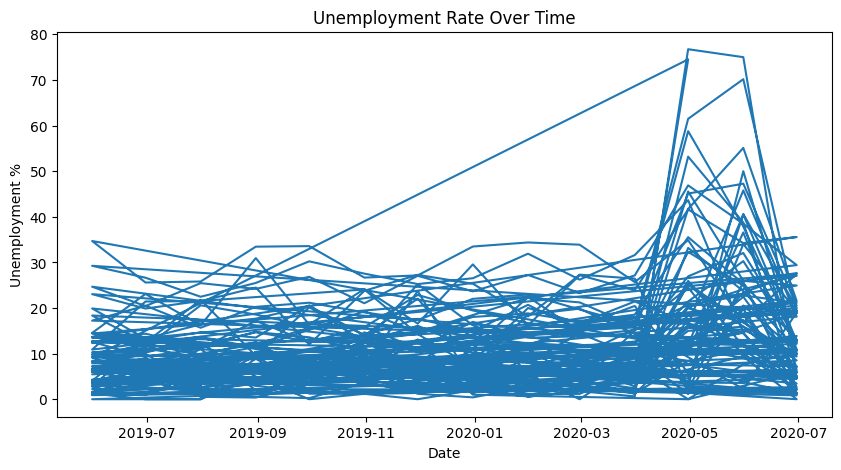

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df[' Date'], df[' Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment %")
plt.show()

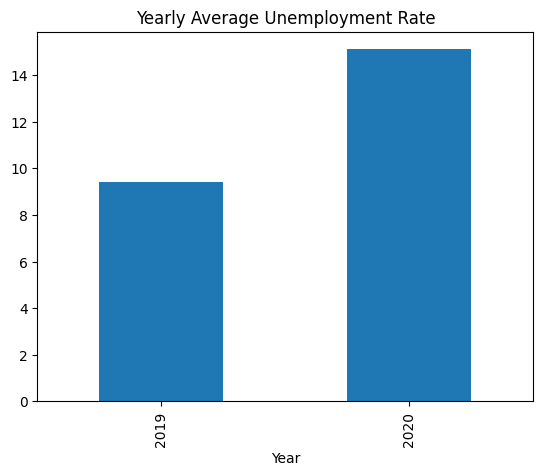

In [ ]:
yearly = df.groupby('Year')[' Estimated Unemployment Rate (%)'].mean()

yearly.plot(kind='bar')
plt.title("Yearly Average Unemployment Rate")
plt.show()

In [ ]:
pre_covid=df[df['Year']<2020]
covid=df[df['Year']>=2020]

In [ ]:
print("Pre_covid Avg:",pre_covid[' Estimated Unemployment Rate (%)'].mean())

Pre_covid Avg: 9.399046511627906


In [ ]:
print("covid Avg:",covid[' Estimated Unemployment Rate (%)'].mean())

covid Avg: 15.10158064516129


<Axes: xlabel='Year', ylabel=' Estimated Unemployment Rate (%)'>

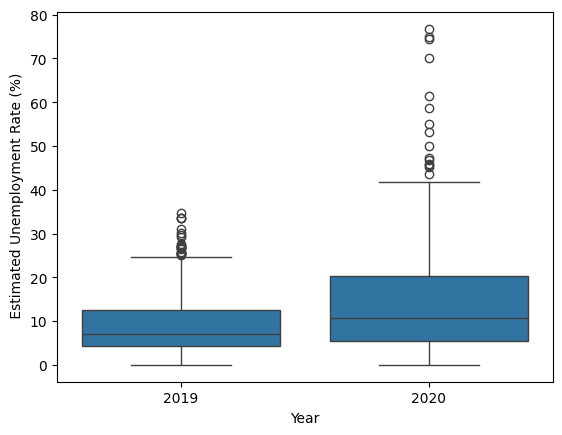

In [ ]:
sns.boxplot(x='Year',y=' Estimated Unemployment Rate (%)',data=df[df['Year']>=2018])
plt.title("Covid impact on Unemployment")
plt.show()

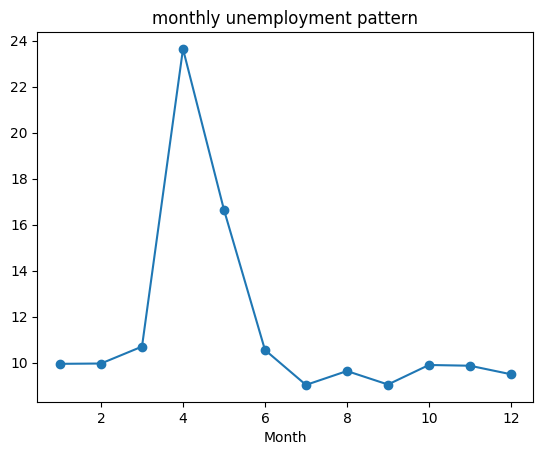

In [ ]:
monthly=df.groupby('Month')[' Estimated Unemployment Rate (%)'].mean()
monthly.plot(kind='line', marker='o')
plt.title("monthly unemployment pattern")
plt.show()